# Tai Dinh, Week 8, Evaluation Expansion

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn import linear_model as lm
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error as mape

from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

In [4]:
#custom mdape function
def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true))

# Load in CSV's, Remove Outliers, and Select Features

In [5]:
test_df = pd.read_csv('/content/test_df.csv')
valid_df = pd.read_csv('/content/valid_df.csv')
train_df = pd.read_csv('/content/train_df.csv')

/tmp/ipykernel_3490/319966960.py:1: DtypeWarning: Columns (118,175) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv('/content/test_df.csv')
/tmp/ipykernel_3490/319966960.py:2: DtypeWarning: Columns (118) have mixed types. Specify dtype option on import or set low_memory=False.
  valid_df = pd.read_csv('/content/valid_df.csv')
/tmp/ipykernel_3490/319966960.py:3: DtypeWarning: Columns (118,175) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('/content/train_df.csv')


In [6]:
train_df = train_df[(train_df["ClosePrice"] <= 600000000) & (train_df["ClosePrice"] > 0)]

In [7]:
cols = ["LivingArea", "Age", "Bed/Bath Ratio", "Living Area per Bedroom", "ParkingTotal", "BathroomsTotalInteger", "GarageSpaces", "AttachedGarageYN", "PoolPrivateYN", "ViewYN", "BedroomsTotal", "Stories", "AssociationFee"
, "AssociationFeeFrequency_Monthly", "AssociationFeeFrequency_None", "AssociationFeeFrequency_Quarterly", "AssociationFeeFrequency_SemiAnnually"
, 'CountyOrParish_Amador',
 'CountyOrParish_Butte',
 'CountyOrParish_Calaveras',
 'CountyOrParish_Clark',
 'CountyOrParish_Colusa',
 'CountyOrParish_Contra Costa',
 'CountyOrParish_El Dorado',
 'CountyOrParish_Foreign Country',
 'CountyOrParish_Fresno',
 'CountyOrParish_Glenn',
 'CountyOrParish_Humboldt',
 'CountyOrParish_Imperial',
 'CountyOrParish_Inyo',
 'CountyOrParish_Kern',
 'CountyOrParish_Kings',
 'CountyOrParish_Lake',
 'CountyOrParish_Lassen',
 'CountyOrParish_Los Angeles',
 'CountyOrParish_Madera',
 'CountyOrParish_Marin',
 'CountyOrParish_Mariposa',
 'CountyOrParish_Mendocino',
 'CountyOrParish_Merced',
 'CountyOrParish_Modoc',
 'CountyOrParish_Mono',
 'CountyOrParish_Monterey',
 'CountyOrParish_Napa',
 'CountyOrParish_Nevada',
 'CountyOrParish_Orange',
 'CountyOrParish_Other',
 'CountyOrParish_Other State',
 'CountyOrParish_Placer',
 'CountyOrParish_Plumas',
 'CountyOrParish_Riverside',
 'CountyOrParish_Sacramento',
 'CountyOrParish_San Benito',
 'CountyOrParish_San Bernardino',
 'CountyOrParish_San Diego',
 'CountyOrParish_San Francisco',
 'CountyOrParish_San Joaquin',
 'CountyOrParish_San Luis Obispo',
 'CountyOrParish_San Mateo',
 'CountyOrParish_Santa Barbara',
 'CountyOrParish_Santa Clara',
 'CountyOrParish_Santa Cruz',
 'CountyOrParish_Shasta',
 'CountyOrParish_Sierra',
 'CountyOrParish_Siskiyou',
 'CountyOrParish_Solano',
 'CountyOrParish_Sonoma',
 'CountyOrParish_Stanislaus',
 'CountyOrParish_Sutter',
 'CountyOrParish_Tehama',
 'CountyOrParish_Trinity',
 'CountyOrParish_Tulare',
 'CountyOrParish_Tuolumne',
 'CountyOrParish_Ventura',
 'CountyOrParish_Yolo',
 'CountyOrParish_Yuba',
 'DistrictName_Apple Valley Unified',
 'DistrictName_Bear Valley Unified',
 'DistrictName_Beaumont Unified',
 'DistrictName_Capistrano Unified',
 'DistrictName_Chico Unified',
 'DistrictName_Chino Valley Unified',
 'DistrictName_Coachella Valley Unified',
 'DistrictName_Conejo Valley Unified',
 'DistrictName_Corona-Norco Unified',
 'DistrictName_Desert Sands Unified',
 'DistrictName_Fontana Unified',
 'DistrictName_Fremont Unified',
 'DistrictName_Garden Grove Unified',
 'DistrictName_Glendale Unified',
 'DistrictName_Hemet Unified',
 'DistrictName_Hesperia Unified',
 'DistrictName_Irvine Unified',
 'DistrictName_Lake Elsinore Unified',
 'DistrictName_Long Beach Unified',
 'DistrictName_Los Angeles Unified',
 'DistrictName_Lucia Mar Unified',
 'DistrictName_Moreno Valley Unified',
 'DistrictName_Morongo Unified',
 'DistrictName_Mt. Diablo Unified',
 'DistrictName_Murrieta Valley Unified',
 'DistrictName_Newport-Mesa Unified',
 'DistrictName_None',
 'DistrictName_Oakland Unified',
 'DistrictName_Oceanside Unified',
 'DistrictName_Orange Unified',
 'DistrictName_Other',
 'DistrictName_Palm Springs Unified',
 'DistrictName_Pasadena Unified',
 'DistrictName_Placentia-Yorba Linda Unified',
 'DistrictName_Poway Unified',
 'DistrictName_Redlands Unified',
 'DistrictName_Rim of the World Unified',
 'DistrictName_Riverside Unified',
 'DistrictName_Saddleback Valley Unified',
 'DistrictName_San Bernardino City Unified',
 'DistrictName_San Diego Unified',
 'DistrictName_San Jose Unified',
 'DistrictName_San Marcos Unified',
 'DistrictName_San Ramon Valley Unified',
 'DistrictName_Simi Valley Unified',
 'DistrictName_Temecula Valley Unified',
 'DistrictName_Torrance Unified',
 'DistrictName_Vista Unified',
 'DistrictName_West Contra Costa Unified']
X_train = train_df[cols]
Y_train = train_df["ClosePrice"]

X_valid = valid_df[cols]
Y_valid = valid_df["ClosePrice"]

X_test = test_df[cols]
Y_test = test_df["ClosePrice"]

#Baseline Model Metrics

r^2: 0.3903779014376554
RMSE: 1308935.3209881429
MAPE: 0.4626403434124463
MDAPE: 0.2934006112767211


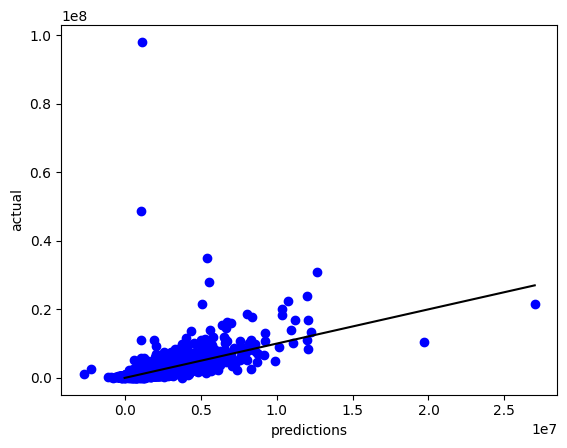

In [8]:
base_model = lm.LinearRegression()
base_model.fit(X_train, Y_train)

#validation set metrics
vlin_preds = base_model.predict(X_valid)
print(f"r^2: {r2_score(Y_valid, vlin_preds)}")
print(f"RMSE: {root_mean_squared_error(Y_valid, vlin_preds)}")
print(f"MAPE: {mape(Y_valid, vlin_preds)}")
print(f"MDAPE: {mdape(Y_valid, vlin_preds)}")

#plotting predictions vs. actual
plt.scatter(vlin_preds, Y_valid, color='blue')
plt.plot([0, max(vlin_preds)], [0, max(vlin_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

r^2: 0.5912357989002195
RMSE: 981831.4434953366
MAPE: 0.5089706866611853
MDAPE: 0.28975834004120876


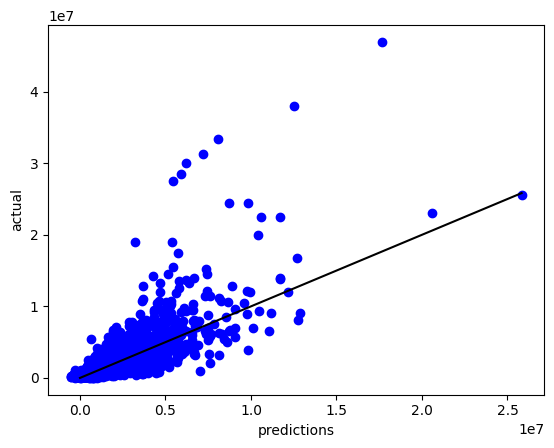

In [9]:
#test set metrics
tlin_preds = base_model.predict(X_test)
print(f"r^2: {r2_score(Y_test, tlin_preds)}")
print(f"RMSE: {root_mean_squared_error(Y_test, tlin_preds)}")
print(f"MAPE: {mape(Y_test, tlin_preds)}")
print(f"MDAPE: {mdape(Y_test, tlin_preds)}")

#plotting predictions vs. actual
plt.scatter(tlin_preds, Y_test, color='blue')
plt.plot([0, max(tlin_preds)], [0, max(tlin_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

#Decision Tree Regressor

In [10]:
#initialize decision tree regressor
tree = DecisionTreeRegressor(random_state=30, max_depth = 30, min_samples_split = 200)

r^2: 0.3413856343881939
RMSE: 1360515.318177254
MAPE: 0.30757212842016524
MDAPE: 0.16198615131578947


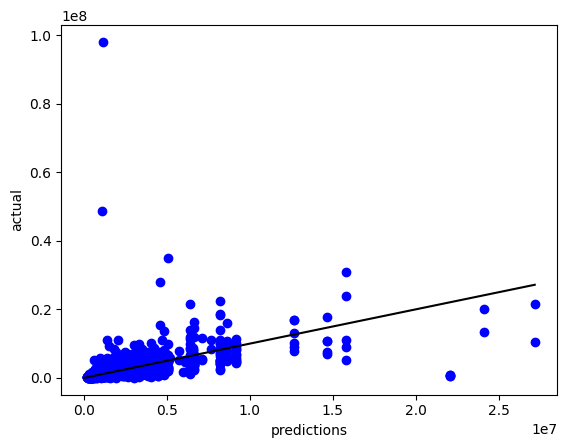

In [11]:
tree.fit(X_train, Y_train)

#validation set metrics
vtree_preds = tree.predict(X_valid)
print(f"r^2: {r2_score(Y_valid, vtree_preds)}")
print(f"RMSE: {root_mean_squared_error(Y_valid, vtree_preds)}")
print(f"MAPE: {mape(Y_valid, vtree_preds)}")
print(f"MDAPE: {mdape(Y_valid, vtree_preds)}")

#plotting predictions vs. actual
plt.scatter(vtree_preds, Y_valid, color='blue')
plt.plot([0, max(vtree_preds)], [0, max(vtree_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

r^2: 0.5899801583822464
RMSE: 983338.2804951846
MAPE: 0.34814981565491837
MDAPE: 0.1579951581392892


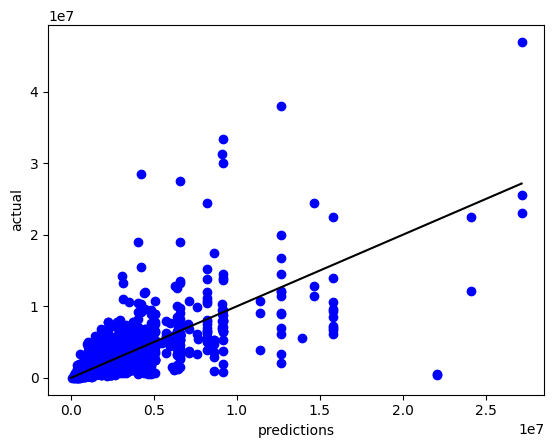

In [12]:
#test set metrics
testtree_preds = tree.predict(X_test)
print(f"r^2: {r2_score(Y_test, testtree_preds)}")
print(f"RMSE: {root_mean_squared_error(Y_test, testtree_preds)}")
print(f"MAPE: {mape(Y_test, testtree_preds)}")
print(f"MDAPE: {mdape(Y_test, testtree_preds)}")

#plotting predictions vs. actual
plt.scatter(testtree_preds, Y_test, color='blue')
plt.plot([0, max(testtree_preds)], [0, max(testtree_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

#Random Forest Regressor

r^2: 0.4115664909556296
RMSE: 1285986.8697890178
MAPE: 0.30930699003416107
MDAPE: 0.16245338005733773


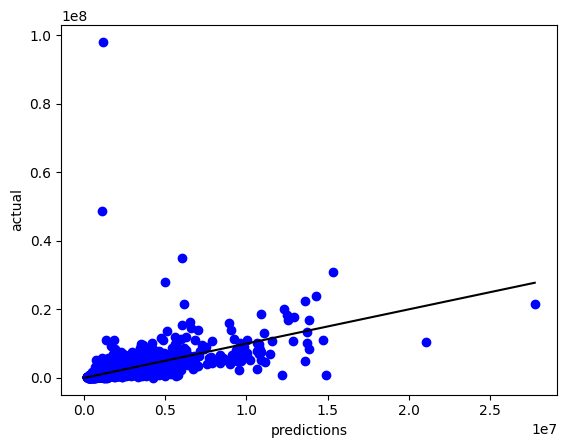

In [13]:
#define random forest regressor
rf = RandomForestRegressor(random_state=30, max_depth = 30, min_samples_split = 200)
rf.fit(X_train, Y_train)

#validation set metrics
vrf_preds = rf.predict(X_valid)
print(f"r^2: {r2_score(Y_valid, vrf_preds)}")
print(f"RMSE: {root_mean_squared_error(Y_valid, vrf_preds)}")
print(f"MAPE: {mape(Y_valid, vrf_preds)}")
print(f"MDAPE: {mdape(Y_valid, vrf_preds)}")

#plotting predictions vs. actual
plt.scatter(vrf_preds, Y_valid, color='blue')
plt.plot([0, max(vrf_preds)], [0, max(vrf_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

r^2: 0.6221649735163861
RMSE: 943955.708937182
MAPE: 0.5493165370039876
MDAPE: 0.15941186032074228


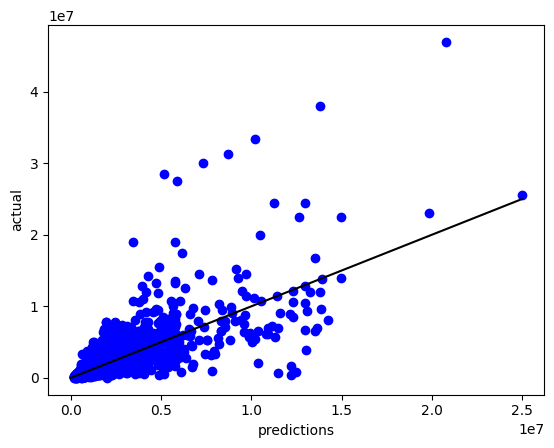

In [14]:
#test set metrics
trf_preds = rf.predict(X_test)
print(f"r^2: {r2_score(Y_test, trf_preds)}")
print(f"RMSE: {root_mean_squared_error(Y_test, trf_preds)}")
print(f"MAPE: {mape(Y_test, trf_preds)}")
print(f"MDAPE: {mdape(Y_test, trf_preds)}")

#plotting predictions vs. actual
plt.scatter(trf_preds, Y_test, color='blue')
plt.plot([0, max(trf_preds)], [0, max(trf_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

#Gradient Boosting

r^2: 0.4134440215035242
RMSE: 1283933.6142724077
MAPE: 0.35877959745012883
MDAPE: 0.21037460191082802


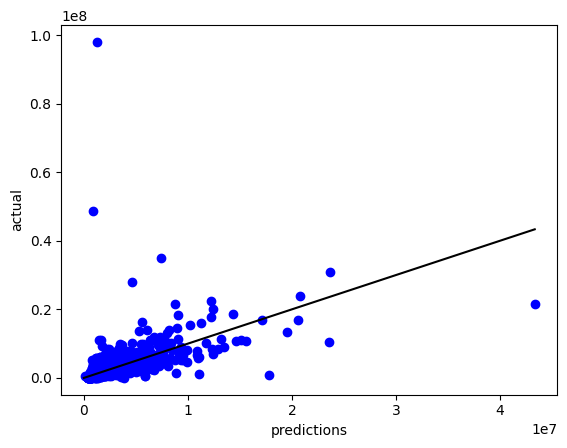

In [15]:
gradmodel = xgb.XGBRegressor(objective='reg:squarederror',
    n_estimators=80,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='rmse')
gradmodel.fit(X_train, Y_train)
vgrad_pred = gradmodel.predict(X_valid)

#validation set metrics
print(f"r^2: {r2_score(Y_valid, vgrad_pred)}")
print(f"RMSE: {root_mean_squared_error(Y_valid, vgrad_pred)}")
print(f"MAPE: {mape(Y_valid, vgrad_pred)}")
print(f"MDAPE: {mdape(Y_valid, vgrad_pred)}")

#plotting predictions vs. actual
plt.scatter(vgrad_pred, Y_valid, color='blue')
plt.plot([0, max(vgrad_pred)], [0, max(vgrad_pred)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

r^2: 0.6602658312184324
RMSE: 895097.045340494
MAPE: 0.41460008004657595
MDAPE: 0.2084646


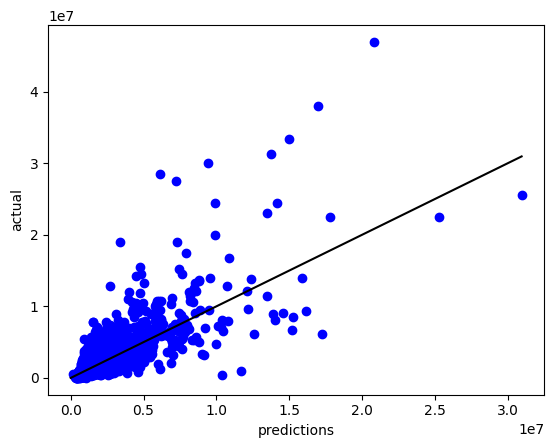

In [16]:
testgrad_pred = gradmodel.predict(X_test)

#test set metrics
print(f"r^2: {r2_score(Y_test, testgrad_pred)}")
print(f"RMSE: {root_mean_squared_error(Y_test, testgrad_pred)}")
print(f"MAPE: {mape(Y_test, testgrad_pred)}")
print(f"MDAPE: {mdape(Y_test, testgrad_pred)}")

#plotting predictions vs. actual
plt.scatter(testgrad_pred, Y_test, color='blue')
plt.plot([0, max(testgrad_pred)], [0, max(testgrad_pred)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

#Metrics Summary

In [17]:
summar = pd.DataFrame(columns = ["Model", "r^2", "RMSE", "MAPE", "MDAPE"])
summar["Model"] = ["Linear Regression", "Decision Tree Regressor", "Random Forest Regressor", "Gradient Boost"]
summar['r^2'] = [r2_score(Y_test, tlin_preds), r2_score(Y_test, testtree_preds), r2_score(Y_test, trf_preds), r2_score(Y_test, testgrad_pred)]
summar['RMSE'] = [root_mean_squared_error(Y_test, tlin_preds), root_mean_squared_error(Y_test, testtree_preds), root_mean_squared_error(Y_test, trf_preds), root_mean_squared_error(Y_test, testgrad_pred)]
summar['MAPE'] = [mape(Y_test, tlin_preds), mape(Y_test, testtree_preds), mape(Y_test, trf_preds), mape(Y_test, testgrad_pred)]
summar['MDAPE'] = [mdape(Y_test, tlin_preds), mdape(Y_test, testtree_preds), mdape(Y_test, trf_preds), mdape(Y_test, testgrad_pred)]
summar
summar.to_csv('metrics_summary.csv', index=False)

Linear Regression is the weakest model by MdAPE, which I'm valuing as the most valuable metric because housing prices have some high outliers. By MDAPE, Decision Tree Regressors are the strongest model, but we have the trade-off of longer computations. By $r^2$, Gradient Boost accounts for the most variance in the model though trails behind in terms of MDAPE. Random Forests and Gradient Boost are my two preferred models here.

#How do these models perform on different price bands?

In [18]:
#taking percentiles to split data into different price bands
target_percentiles = [0.5, 0.8]

print(test_df['ClosePrice'].quantile(target_percentiles))
first_percentile = test_df['ClosePrice'].quantile(target_percentiles[0])
second_percentile = test_df['ClosePrice'].quantile(target_percentiles[1])

first_band = test_df[test_df['ClosePrice'] <= first_percentile]
second_band = test_df[(test_df['ClosePrice'] > first_percentile) & (test_df['ClosePrice'] <= second_percentile)]
third_band = test_df[test_df['ClosePrice'] > second_percentile]

0.5     925000.0
0.8    1665000.0
Name: ClosePrice, dtype: float64


r^2: -1.7528690365527293
RMSE: 309496.89772467164
MAPE: 0.5906650965715784
MDAPE: 0.23345879458794588


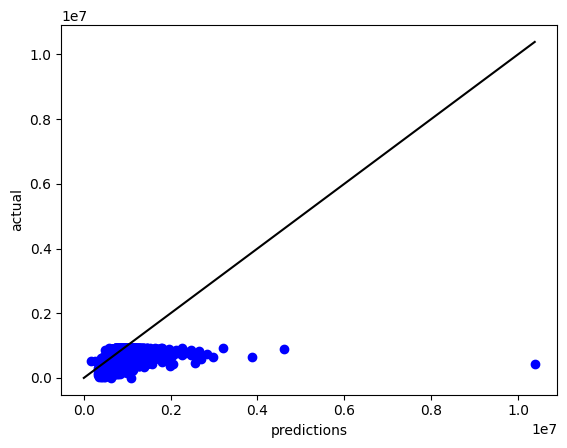

In [19]:
#first percentile  metrics
first_preds = gradmodel.predict(first_band[cols])
print(f"r^2: {r2_score(first_band["ClosePrice"], first_preds)}")
print(f"RMSE: {root_mean_squared_error(first_band["ClosePrice"], first_preds)}")
print(f"MAPE: {mape(first_band["ClosePrice"], first_preds)}")
print(f"MDAPE: {mdape(first_band["ClosePrice"], first_preds)}")

#plotting predictions vs. actual
plt.scatter(first_preds, first_band["ClosePrice"], color='blue')
plt.plot([0, max(first_preds)], [0, max(first_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')
plt.show()

r^2: -2.7761146052355903
RMSE: 412036.54482057964
MAPE: 0.20710829349942309
MDAPE: 0.15517758623637773


Text(0, 0.5, 'actual')

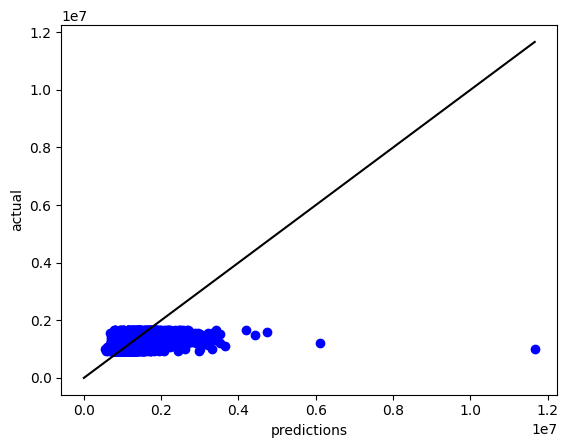

In [20]:
#second percentile metrics
second_preds = gradmodel.predict(second_band[cols])
print(f"r^2: {r2_score(second_band["ClosePrice"], second_preds)}")
print(f"RMSE: {root_mean_squared_error(second_band["ClosePrice"], second_preds)}")
print(f"MAPE: {mape(second_band["ClosePrice"], second_preds)}")
print(f"MDAPE: {mdape(second_band["ClosePrice"], second_preds)}")

#plotting predictions vs. actual
plt.scatter(second_preds, second_band["ClosePrice"], color='blue')
plt.plot([0, max(second_preds)], [0, max(second_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')

r^2: 0.5106259742165421
RMSE: 1875349.7539119523
MAPE: 0.27971327399156587
MDAPE: 0.2520256675224647


Text(0, 0.5, 'actual')

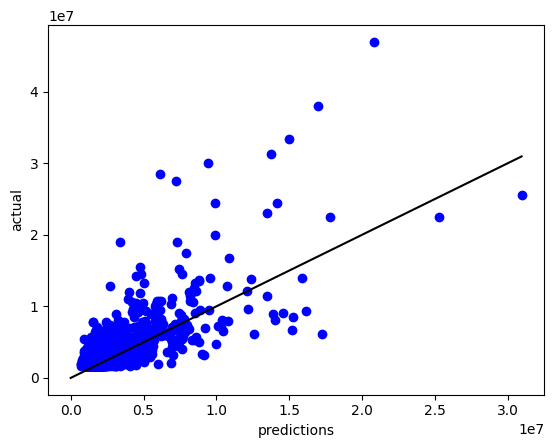

In [21]:
#third percentile metrics
third_preds = gradmodel.predict(third_band[cols])
print(f"r^2: {r2_score(third_band["ClosePrice"], third_preds)}")
print(f"RMSE: {root_mean_squared_error(third_band["ClosePrice"], third_preds)}")
print(f"MAPE: {mape(third_band["ClosePrice"], third_preds)}")
print(f"MDAPE: {mdape(third_band["ClosePrice"], third_preds)}")

#plotting predictions vs. actual
plt.scatter(third_preds, third_band["ClosePrice"], color='blue')
plt.plot([0, max(third_preds)], [0, max(third_preds)], color = 'black')
plt.xlabel('predictions')
plt.ylabel('actual')